In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(f"./../")
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
from src.misc import *

In [2]:
def collect_graph_properties(filename, n_vertices):
    properties = {
        "edge_counts": [],
        "edge_densities": [],
        "bipartite_counts": defaultdict(int),
        "diameters": [],
        "clique_numbers": [],
        "max_degrees": [],
        "clustering_coefficients": [],
        "group_sizes": [],
        "orbit_counts": [],
    }

    with open(filename, "r") as file:
        for line in file:
            try:
                G = nx.from_graph6_bytes(line.strip().encode("utf-8"))
                
                # Calculate properties using G directly
                properties["edge_counts"].append(count_edges(G))
                properties["edge_densities"].append(calculate_edge_density(G))
                properties["bipartite_counts"][is_bipartite(G)] += 1

                if nx.is_connected(G):
                    properties["diameters"].append(find_diameter(G))

                properties["clique_numbers"].append(find_max_clique(G))
                properties["max_degrees"].append(max(G.degree(node) for node in G.nodes()))
                properties["clustering_coefficients"].append(average_clustering(G))
                properties["group_sizes"].append(estimate_group_size(G))
                properties["orbit_counts"].append(estimate_orbit_count(G))

            except nx.NetworkXError as e:
                print(f"Error processing graph: {e}")

    return properties

def plot_comparison_histogram(data_by_category, title, xlabel, ylabel, filename):
    plt.figure(figsize=(15, 10))
    
    # Count total graphs in each category from the actual input files
    category_sizes = {}
    for category in data_by_category.keys():
        category_sizes[category] = len(data_by_category[category])
        print(f"Category {category} has {category_sizes[category]} graphs")
    
    # Combine all data for binning
    all_data = []
    for data in data_by_category.values():
        if len(data) > 0:
            all_data.extend(data)
    
    if not all_data:
        print(f"No data available for {xlabel}")
        return
        
    bins = np.histogram(all_data, bins=30)[1]
    
    # Sort categories by their size (descending)
    ordered_categories = sorted(
        list(category_sizes.keys()),
        key=lambda x: category_sizes[x],
        reverse=True  # This makes it descending order
    )
    
    print("Plotting order:", ordered_categories)
    
    # Plot histogram with largest categories in back (plot in descending order)
    for category in ordered_categories:
        if category in data_by_category and len(data_by_category[category]) > 0:
            plt.hist(data_by_category[category], 
                    bins=bins, 
                    label=f"{category.replace('_', ' ').title()}",
                    color=CATEGORIES[category], 
                    alpha=0.7,
                    histtype='bar', 
                    edgecolor='black')
    
    plt.title(title, pad=20)
    plt.xlabel(xlabel, labelpad=15)
    plt.ylabel(ylabel, labelpad=15)
    plt.legend(prop={'size': 15}, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tick_params(axis='both', which='major', labelsize=20, length=10, width=2)
    plt.tick_params(axis='both', which='minor', labelsize=15, length=5, width=1)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
def plot_comparison_bar(data_by_category, title, xlabel, ylabel, filename):
    plt.figure(figsize=(15, 10))
    
    x = np.arange(2)
    num_categories = len(CATEGORIES)
    width = 0.8 / num_categories
    
    for i, (category, color) in enumerate(CATEGORIES.items()):
        if category in data_by_category:
            data = data_by_category[category]
            plt.bar(x + (i - num_categories/2 + 0.5) * width, 
                   [data[False], data[True]], width,
                   label=category.replace('_', ' ').title(), 
                   color=color, edgecolor='black')
    
    plt.title(title, pad=20)
    plt.xlabel(xlabel, labelpad=15)
    plt.ylabel(ylabel, labelpad=15)
    plt.xticks(x, ['Non-bipartite', 'Bipartite'])
    plt.legend(prop={'size': 15}, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tick_params(axis='both', which='major', labelsize=20)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


In [3]:
# Plot parameters
plt.rcParams['font.size'] = 26
plt.rcParams['axes.labelsize'] = 30
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 25

# Configuration
n_vertices = 2**3
plots_folder = '../data/plots/'
dataset = 'BM' #'losing' #'bipartite'  # or 'BM'
# ANALYSIS_TYPE = 'three_way'  # or 'matching_vs_pauli' or 'matching_vs_exact'
ANALYSIS_TYPE = 'matching_vs_pauli'  # or 'matching_vs_pauli' or 'matching_vs_exact'

# Define analysis type and categories with their colors
ANALYSIS_CONFIGS = {
    'matching_vs_pauli': {
        'categories': {
            'win': '#0343df',   # blue
            'lose': '#e50000',  # red
            'draw': '#ffd700'   # yellow
        }
    },
    'matching_vs_exact': {
        'categories': {
            'win': '#0343df',   # blue
            'lose': '#e50000',  # red
            'draw': '#ffd700'   # yellow
        }
    },
    'three_way': {
        'categories': {
            'win_both': '#0343df',              # blue
            'lose_both': '#e50000',             # red
            'draw_both': '#ffd700',             # yellow
            'win_exact_lose_pauli': '#32CD32',  # lime green
            'win_pauli_lose_exact': '#FF8C00',  # dark orange
            'draw_exact_win_pauli': '#9370DB',  # medium purple
            'draw_exact_lose_pauli': '#20B2AA', # light sea green
            'win_exact_draw_pauli': '#FFB6C1',  # light pink
            'lose_exact_draw_pauli': '#BDB76B'  # dark khaki
        }
    }
}

# Select analysis type
CATEGORIES = ANALYSIS_CONFIGS[ANALYSIS_TYPE]['categories']

# Collect properties for all categories
props_by_category = {}
for category in CATEGORIES.keys():
    filename = f'../outputs/matching_vs_pauli/results/{category}_{dataset}_{n_vertices}c.g6'
    # filename = f'../data/graphs/{category}_{ANALYSIS_TYPE}_{dataset}_{n_vertices}c.g6'
    try:
        props_by_category[category] = collect_graph_properties(filename, n_vertices)
        print(f"Successfully processed category: {category}")
    except FileNotFoundError:
        print(f"Warning: No file found for category {category}")
        continue



Successfully processed category: win
Successfully processed category: lose
Successfully processed category: draw


Category win has 1366 graphs
Category lose has 9603 graphs
Category draw has 148 graphs
Plotting order: ['lose', 'win', 'draw']


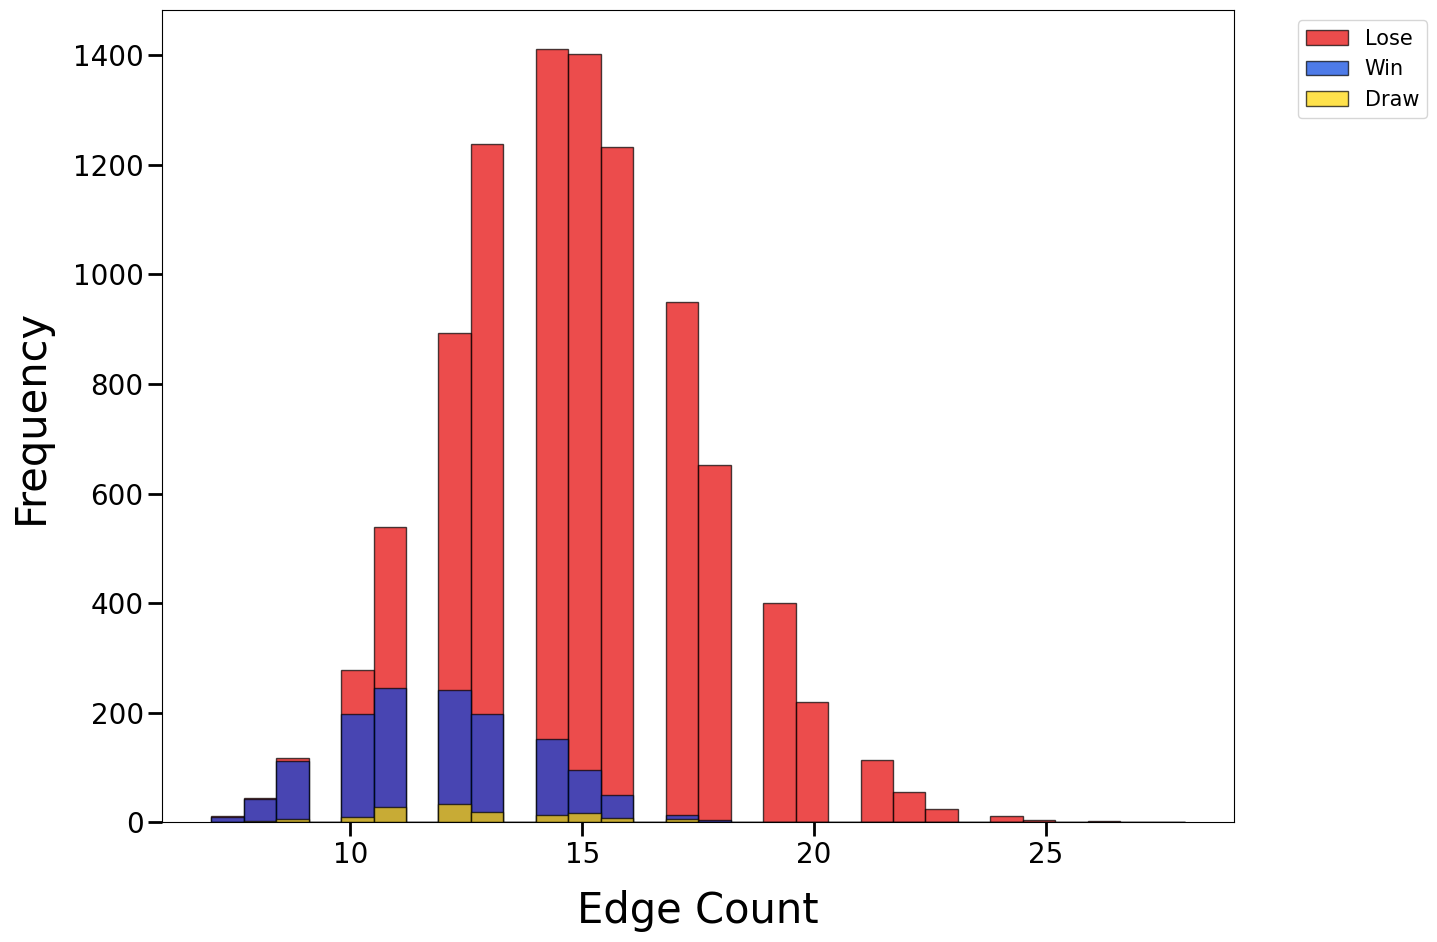

Category win has 1366 graphs
Category lose has 9603 graphs
Category draw has 148 graphs
Plotting order: ['lose', 'win', 'draw']


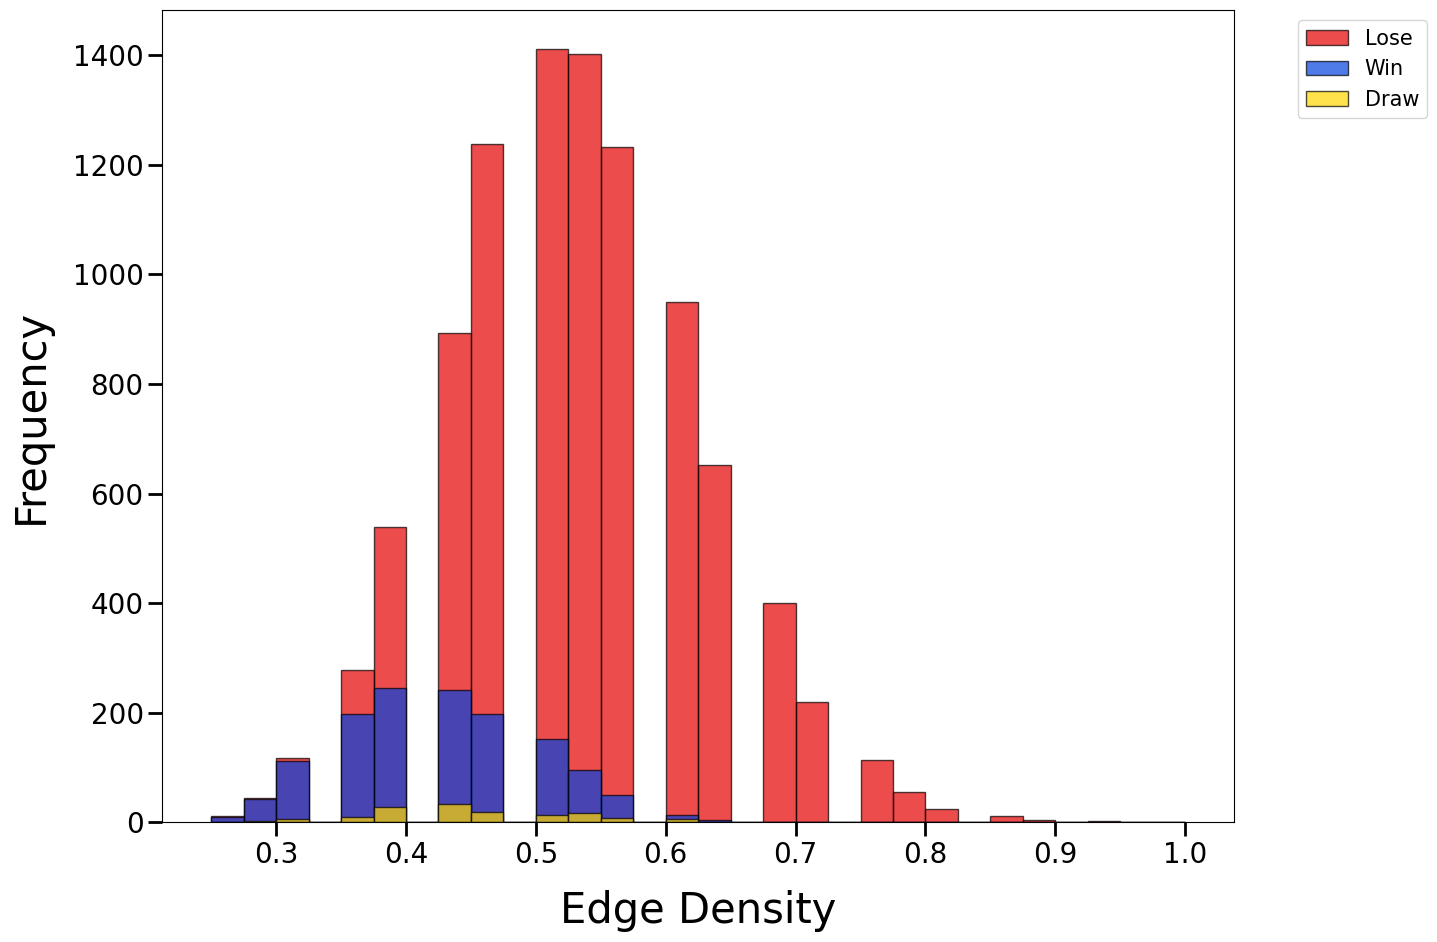

Category win has 1366 graphs
Category lose has 9603 graphs
Category draw has 148 graphs
Plotting order: ['lose', 'win', 'draw']


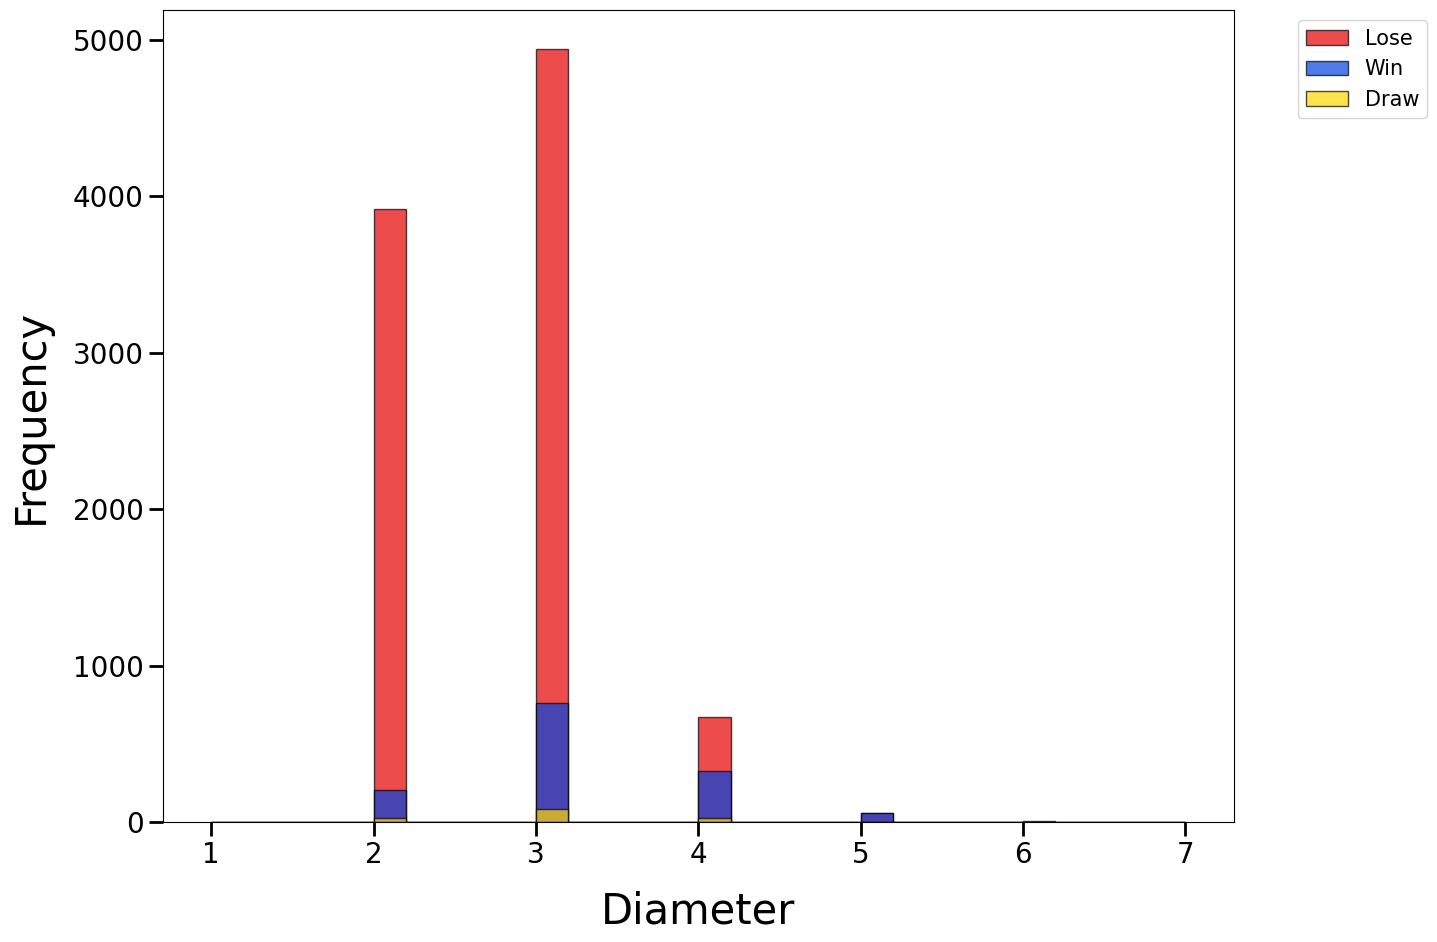

Category win has 1366 graphs
Category lose has 9603 graphs
Category draw has 148 graphs
Plotting order: ['lose', 'win', 'draw']


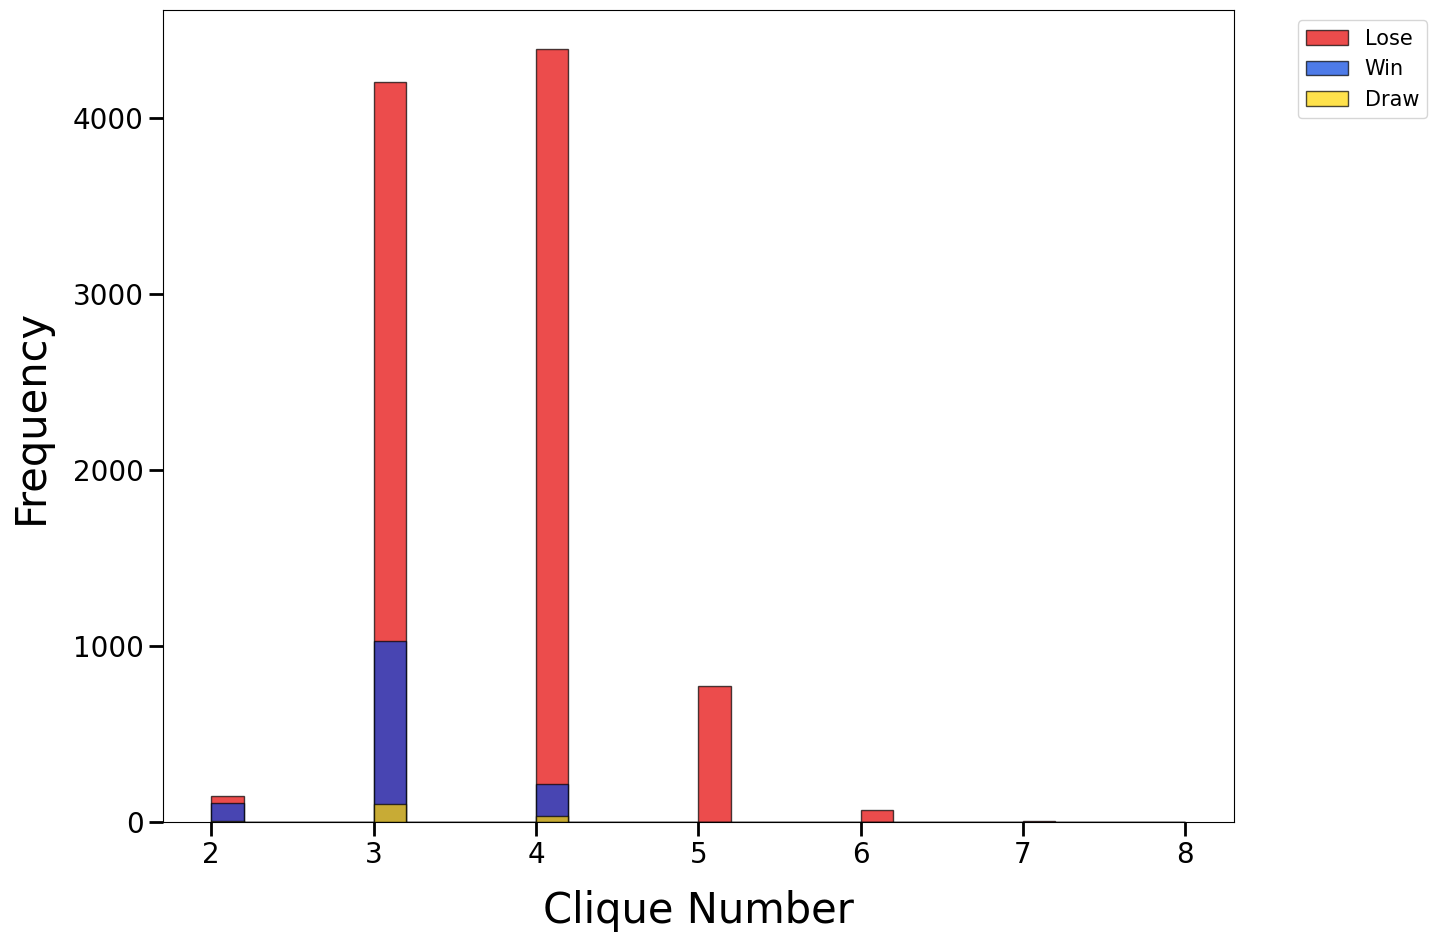

Category win has 1366 graphs
Category lose has 9603 graphs
Category draw has 148 graphs
Plotting order: ['lose', 'win', 'draw']


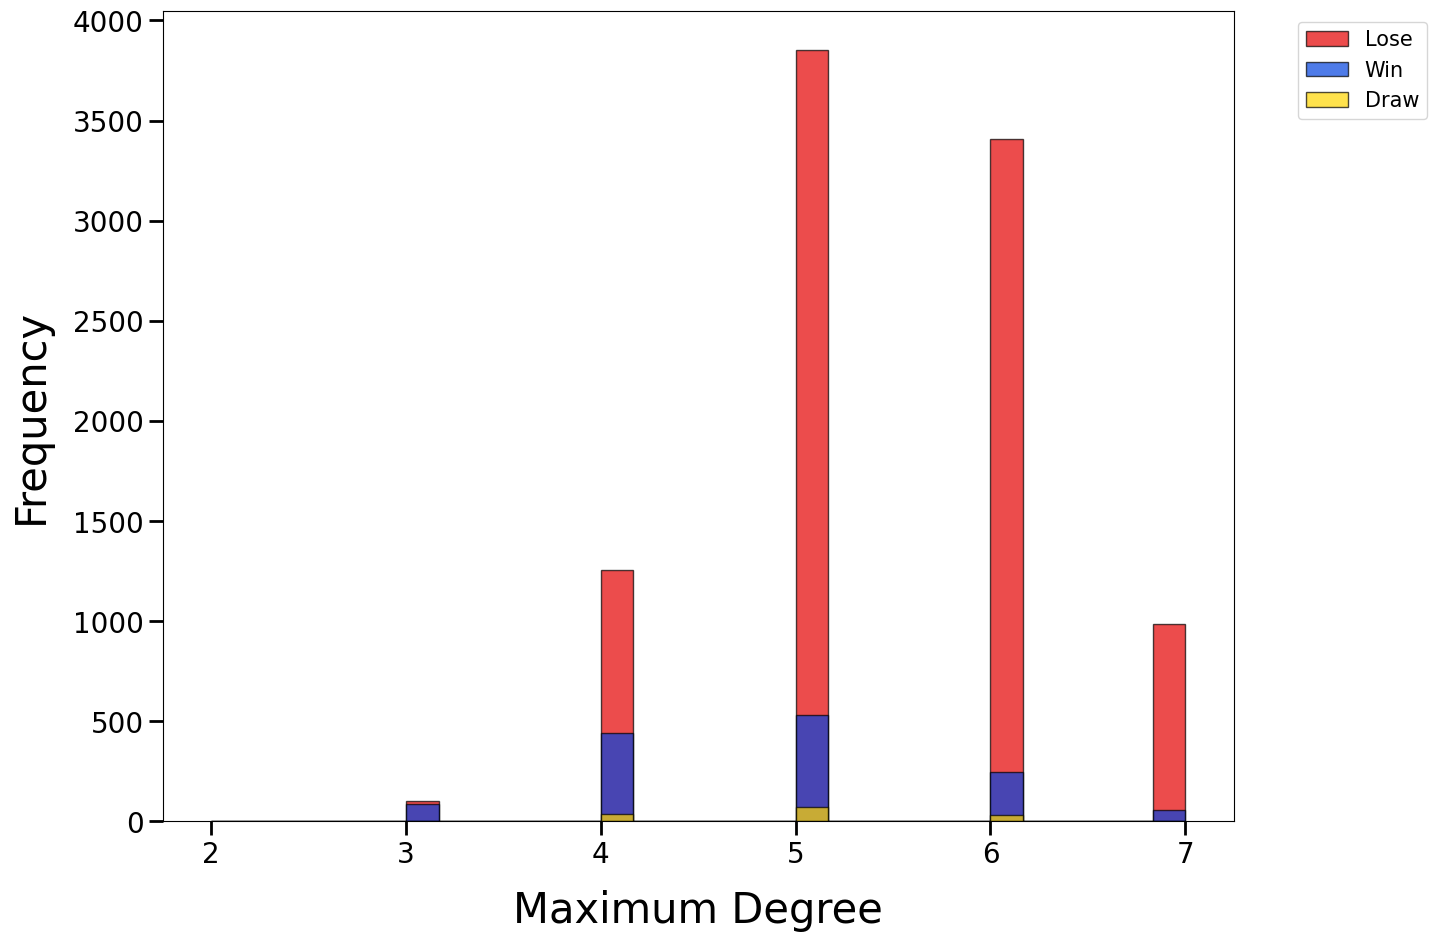

Category win has 1366 graphs
Category lose has 9603 graphs
Category draw has 148 graphs
Plotting order: ['lose', 'win', 'draw']


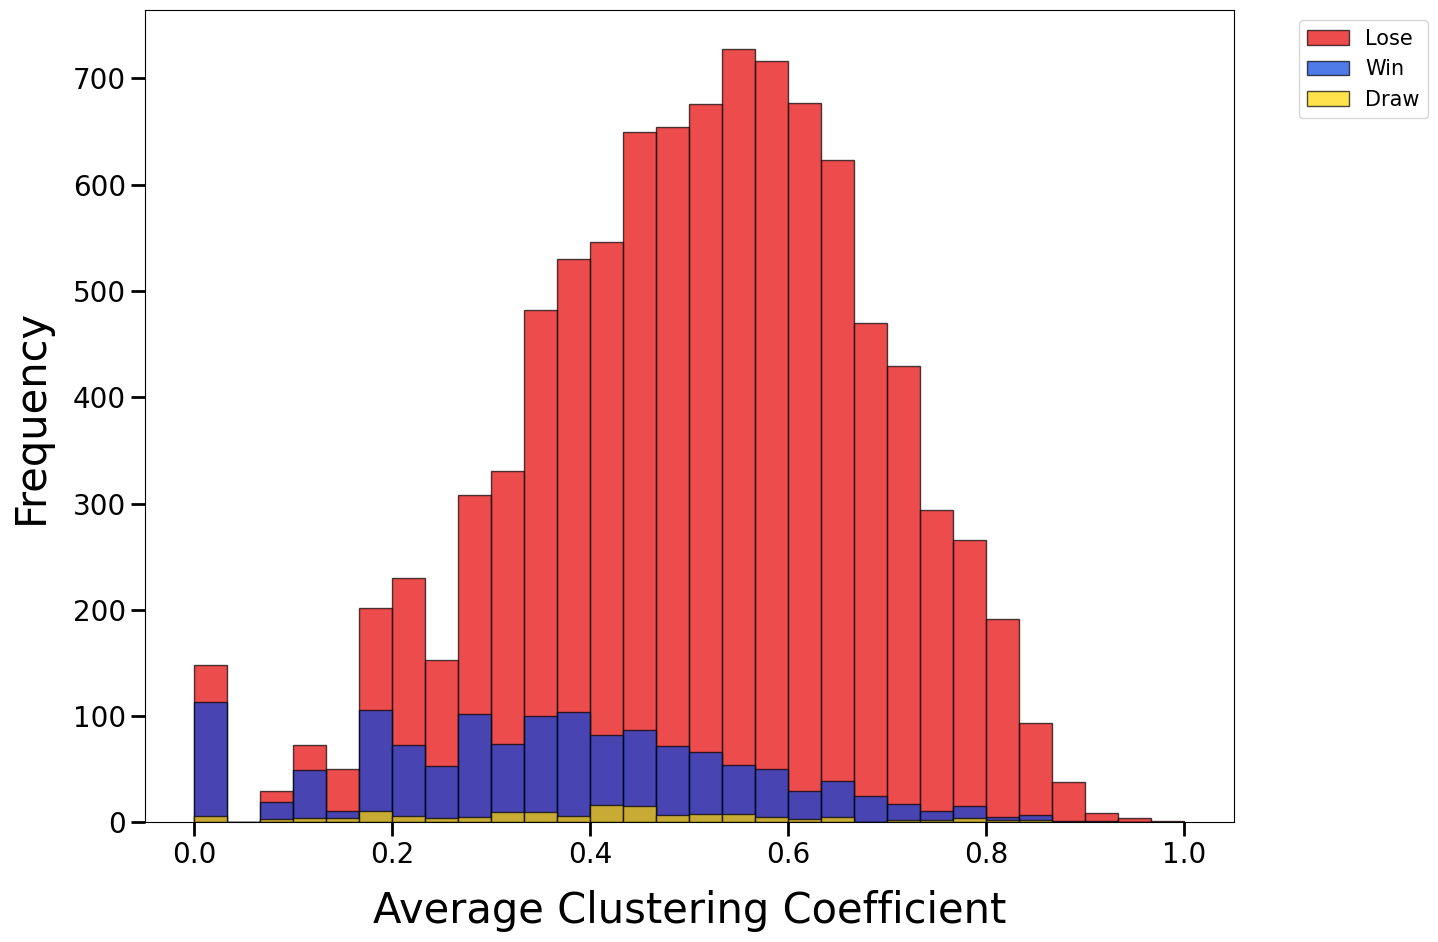

Category win has 1366 graphs
Category lose has 9603 graphs
Category draw has 148 graphs
Plotting order: ['lose', 'win', 'draw']


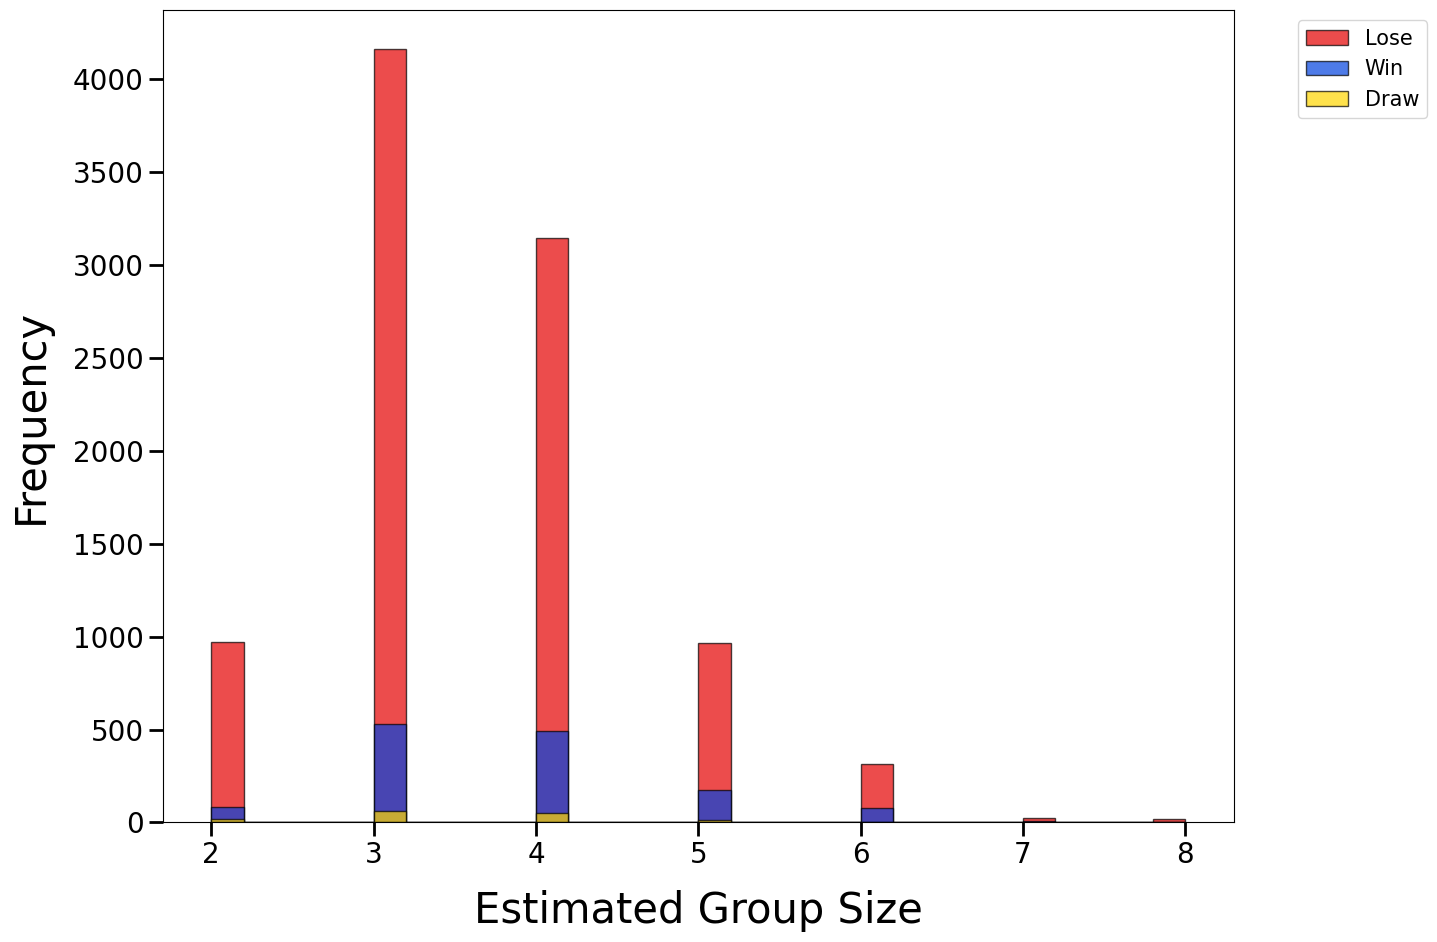

Category win has 1366 graphs
Category lose has 9603 graphs
Category draw has 148 graphs
Plotting order: ['lose', 'win', 'draw']


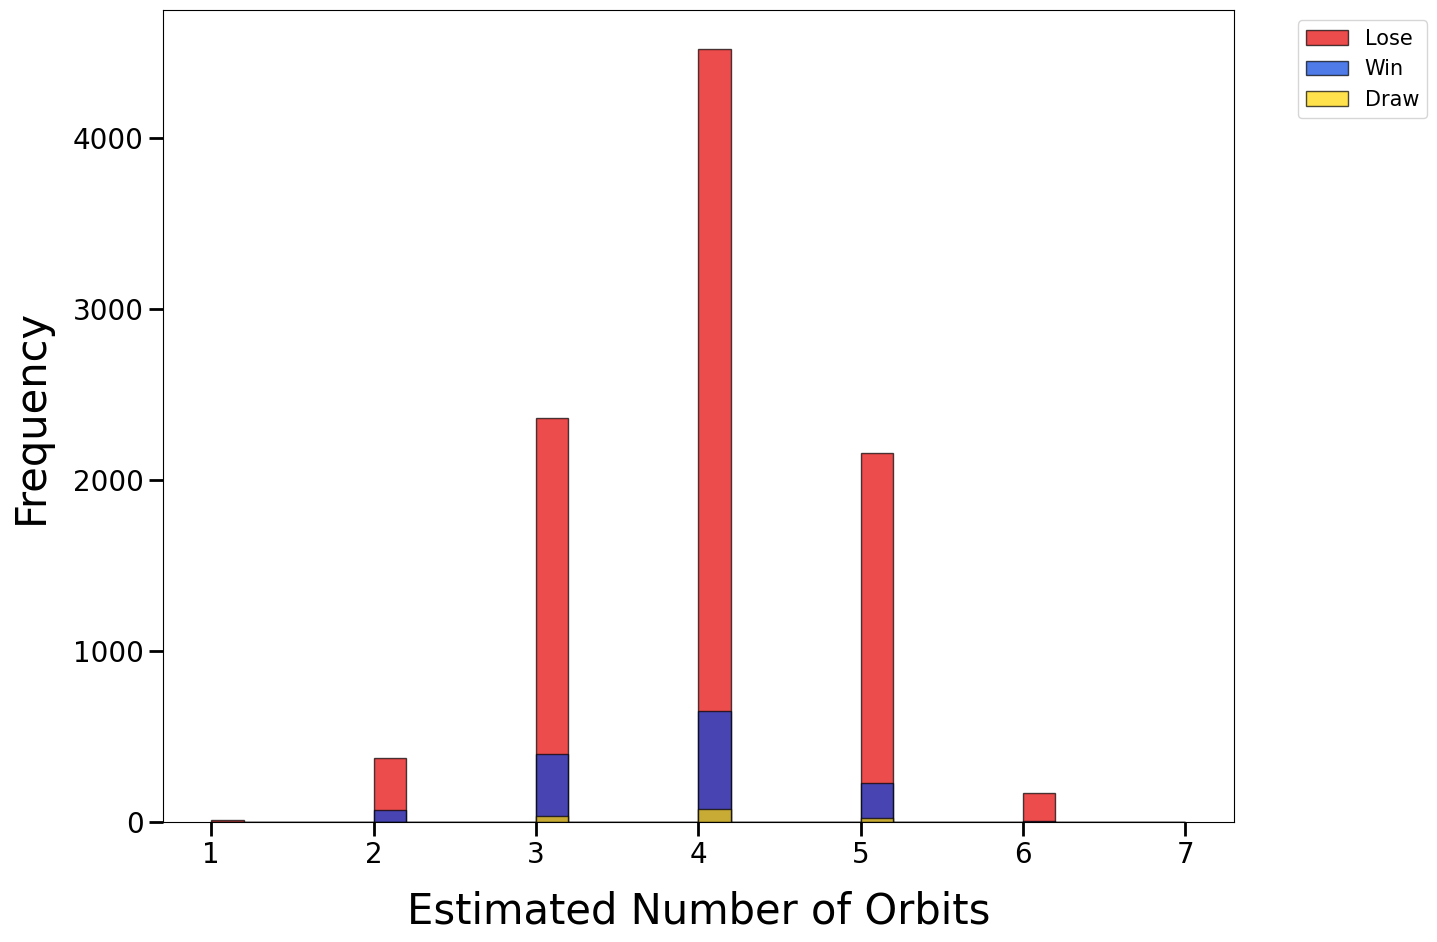

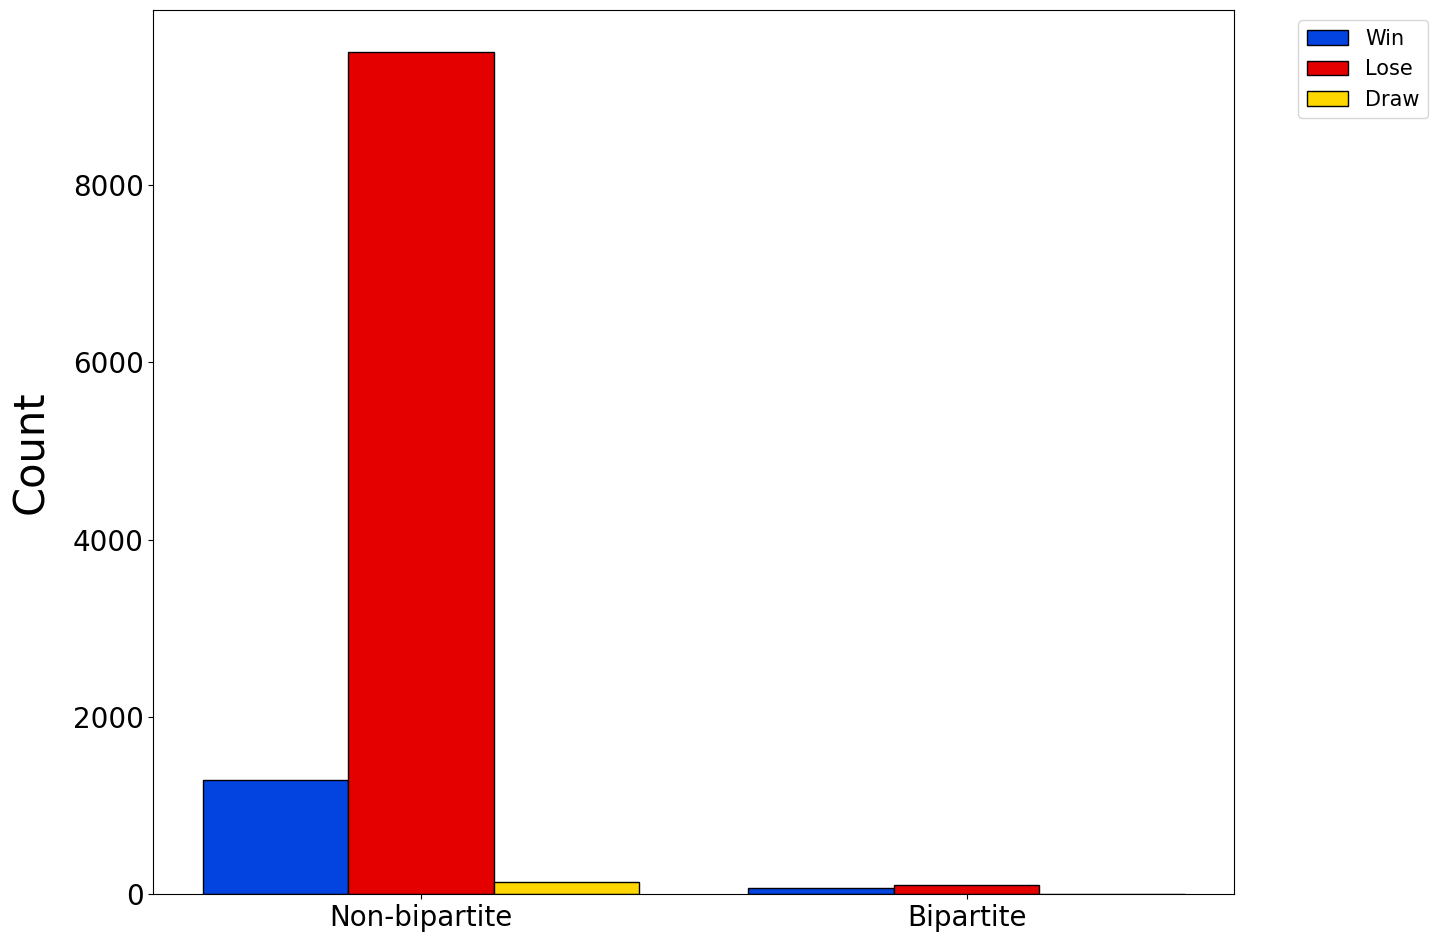

In [4]:
# Generate all comparison plots
properties_to_plot = [
    ('edge_counts', 'Edge Count', 'Frequency'),
    ('edge_densities', 'Edge Density', 'Frequency'),
    ('diameters', 'Diameter', 'Frequency'),
    ('clique_numbers', 'Clique Number', 'Frequency'),
    ('max_degrees', 'Maximum Degree', 'Frequency'),
    ('clustering_coefficients', 'Average Clustering Coefficient', 'Frequency'),
    ('group_sizes', 'Estimated Group Size', 'Frequency'),
    ('orbit_counts', 'Estimated Number of Orbits', 'Frequency')
]

# Plot histograms for each property
for prop, xlabel, ylabel in properties_to_plot:
    if prop != 'bipartite_counts':
        data_by_category = {cat: props[prop] for cat, props in props_by_category.items()}
        plot_comparison_histogram(
            data_by_category,
            '',
            xlabel,
            ylabel,
            f"{plots_folder}{prop}_comparison_{ANALYSIS_TYPE}_{dataset}_{n_vertices}c.pdf"
        )

# Plot bipartite comparison
bipartite_data = {cat: props['bipartite_counts'] 
                 for cat, props in props_by_category.items()}
plot_comparison_bar(
    bipartite_data,
    '',
    '',
    'Count',
    f"{plots_folder}bipartiteness_comparison_{ANALYSIS_TYPE}_{dataset}_{n_vertices}c.pdf"
)


In [5]:
# Print statistics for all categories
print("\nDetailed Statistics by Category:")
print("="*50)

for category in CATEGORIES:
    if category in props_by_category:
        props = props_by_category[category]
        if len(props['edge_counts']) > 0:  # Only print if we have data
            print(f"\n{category.replace('_', ' ').title()} Graphs Statistics:")
            print(f"Total graphs processed: {len(props['edge_counts'])}")
            print(f"Edge count - Min: {min(props['edge_counts'])}, "
                  f"Max: {max(props['edge_counts'])}, "
                  f"Mean: {np.mean(props['edge_counts']):.2f}")
            print(f"Edge density - Min: {min(props['edge_densities']):.4f}, "
                  f"Max: {max(props['edge_densities']):.4f}, "
                  f"Mean: {np.mean(props['edge_densities']):.4f}")
            print(f"Bipartite graphs: {props['bipartite_counts'][True]}, "
                  f"Non-bipartite graphs: {props['bipartite_counts'][False]}")
            if props['diameters']:
                print(f"Diameter - Min: {min(props['diameters'])}, "
                      f"Max: {max(props['diameters'])}, "
                      f"Mean: {np.mean(props['diameters']):.2f}")
            print(f"Clique number - Min: {min(props['clique_numbers'])}, "
                  f"Max: {max(props['clique_numbers'])}, "
                  f"Mean: {np.mean(props['clique_numbers']):.2f}")
            print(f"Maximum degree - Min: {min(props['max_degrees'])}, "
                  f"Max: {max(props['max_degrees'])}, "
                  f"Mean: {np.mean(props['max_degrees']):.2f}")
            print(f"Clustering coefficient - Min: {min(props['clustering_coefficients']):.4f}, "
                  f"Max: {max(props['clustering_coefficients']):.4f}, "
                  f"Mean: {np.mean(props['clustering_coefficients']):.4f}")
            print(f"Estimated group size - Min: {min(props['group_sizes'])}, "
                  f"Max: {max(props['group_sizes'])}, "
                  f"Mean: {np.mean(props['group_sizes']):.2f}")
            print(f"Estimated orbit count - Min: {min(props['orbit_counts'])}, "
                  f"Max: {max(props['orbit_counts'])}, "
                  f"Mean: {np.mean(props['orbit_counts']):.2f}")



Detailed Statistics by Category:

Win Graphs Statistics:
Total graphs processed: 1366
Edge count - Min: 7, Max: 18, Mean: 11.92
Edge density - Min: 0.2500, Max: 0.6429, Mean: 0.4257
Bipartite graphs: 75, Non-bipartite graphs: 1291
Diameter - Min: 2, Max: 6, Mean: 3.19
Clique number - Min: 2, Max: 5, Mean: 3.08
Maximum degree - Min: 2, Max: 7, Mean: 4.81
Clustering coefficient - Min: 0.0000, Max: 0.9286, Mean: 0.3577
Estimated group size - Min: 2, Max: 8, Mean: 3.75
Estimated orbit count - Min: 1, Max: 6, Mean: 3.78

Lose Graphs Statistics:
Total graphs processed: 9603
Edge count - Min: 7, Max: 28, Mean: 14.79
Edge density - Min: 0.2500, Max: 1.0000, Mean: 0.5284
Bipartite graphs: 103, Non-bipartite graphs: 9500
Diameter - Min: 1, Max: 7, Mean: 2.68
Clique number - Min: 2, Max: 8, Mean: 3.63
Maximum degree - Min: 2, Max: 7, Mean: 5.41
Clustering coefficient - Min: 0.0000, Max: 1.0000, Mean: 0.5063
Estimated group size - Min: 2, Max: 8, Mean: 3.55
Estimated orbit count - Min: 1, Max: 7,